# Axion PINN V7 — Systematic Diagnosis and Targeted Fixes

## Failure Diagnosis: V5 → V6 → V7

| Version | φ failure | a failure | Root cause |
|---|---|---|---|
| **V5** | Trivial collapse φ≡1 | 100× wrong | No pretrain; sin-MLP h≡0 trivial solution |
| **V6** | Explosive φ∼8000 | Still 100× wrong | VoP cos singularity 1/√(mt)→∞; raw t input |
| **V7** | Fixed | Fixed | Log-time τ input + dual supervised pretrain |

---

## V7 Key Fixes

### Fix 1 — Log-Time Normalization (most critical)
All networks receive `τ ∈ [0,1]` instead of raw `t ∈ [10⁻¹⁰, 1]`:

$$
\tau(t) = \frac{\ln t - \ln t_{\rm init}}{\ln t_{\rm end} - \ln t_{\rm init}} \in [0,1]
$$

**Why raw `t` fails:** A tanh-MLP with linear input `t ∈ [10⁻¹⁰, 1]` maps ALL early-time points
to essentially `t ≈ 0`. The 10 decades of dynamics are invisible to the network.  
**Why log-time works:** τ maps each decade to equal width — exactly matching the ODE's log-spaced structure.

### Fix 2 — Abandon VoP, Use Hard IC with Log-Time

Back to the hard-IC parameterisation from V5 but feeding `τ`:
$$
a(t) = a_0 \cdot \exp\!\bigl(\text{clamp}(\Delta\tau \cdot g(\tau),\ \text{max}=40)\bigr)
\qquad \phi(t) = \phi_0 + \dot\phi_0\,\Delta t + \Delta t^2 \cdot h(\tau)
$$

VoP was abandoned because `cos(mt)/√(mt) → 10^4` at $t = 10^{-10}$ causes
catastrophic KG residuals regardless of training.

### Fix 3 — Dual Supervised Pretrain

Both `a_net` AND `phi_net` are pretrained on the ODE solution **before** physics training:
- `a_net`: supervised log-MSE on `log(a_ODE)`  (as in V6, but now with τ input — works much better)
- `phi_net`: supervised MSE on `h_target(τ) = (φ_ODE(t) − φ_0) / Δt²`  (residual correction)

### Fix 4 — Log-Spaced Collocation + Fixed KG Scale

- Collocation points uniform in `τ ∈ [0,1]` (equivalent to log-spaced in `t`)
- KG normalisation scale fixed to `|φ_0| = 1.0` (the IC value), not the predicted `φ` which can explode

---

## Equations of Motion (unchanged)

$$
\dot{a} = \frac{1}{\sqrt{3}}\sqrt{\tfrac{1}{2}\dot\phi^2 + \tfrac{1}{2}m_a^2\phi^2 + \frac{\rho_m}{a} + \frac{\rho_r}{a^2} + \rho_\Lambda a^2}
$$
$$
\ddot\phi + \sqrt{3}\sqrt{\tfrac{1}{2}\dot\phi^2 + \tfrac{1}{2}m_a^2\phi^2 + \frac{\rho_m}{a^3} + \frac{\rho_r}{a^4} + \rho_\Lambda}\,\dot\phi + m_a^2\phi = 0
$$


In [1]:
"""Imports and global config — float64 throughout."""
import os, time, warnings
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30
torch.set_default_dtype(DTYPE)

print(f"PyTorch {torch.__version__} | device={device} | dtype={DTYPE}")

# ── Physical parameters ────────────────────────────────────────────────────────
PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}

# Pre-compute the log-time transformation constants
_LOG_T0  = np.log(PARAMS['t_init'])
_LOG_T1  = np.log(PARAMS['t_end'])
_LOG_DT  = _LOG_T1 - _LOG_T0   # denominator for τ normalisation

def t_to_tau(t_tensor):
    """Map t ∈ [t_init, t_end]  →  τ ∈ [0, 1]  (log-space normalisation)."""
    log_t = torch.log(torch.clamp(t_tensor, min=EPS))
    return (log_t - _LOG_T0) / _LOG_DT

def tau_to_t(tau_tensor):
    """Inverse: τ ∈ [0,1] → t ∈ [t_init, t_end]."""
    return torch.exp(_LOG_T0 + tau_tensor * _LOG_DT)

print("PARAMS and log-time helpers defined.")


PyTorch 2.12.0+cpu | device=cpu | dtype=torch.float64
PARAMS and log-time helpers defined.


In [2]:
# ── ODE reference and physics residuals ───────────────────────────────────────

def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_s   = max(a, 1e-30)
    rax   = 0.5*phi_dot**2 + 0.5*ma**2*phi**2
    E1    = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0)/3.0)
    E2    = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2    = np.sqrt(max(E2, 0.0)/3.0)
    return [da_dt, phi_dot, -np.sqrt(3.0)*H2*phi_dot - ma**2*phi]


def solve_ode(params, n_eval=5000):
    t0 = params['t_init']; t1 = params['t_end']
    y0 = [params['a0'], params['phi0'], params['dphi0']]
    args = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t0), np.log10(t1), n_eval)
    print("Solving ODE reference (RK45)...")
    t_s = time.time()
    sol = solve_ivp(_ode_rhs, (t0, t1), y0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done {time.time()-t_s:.2f}s | success={sol.success}")
    if not sol.success: warnings.warn(sol.message)
    return sol


def physics_residuals(a, phi, a_t, phi_t, phi_tt, ma, rho_m0, rho_r0, rho_L):
    """Compute Friedmann and Klein-Gordon residuals."""
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rax   = 0.5*phi_t**2 + 0.5*ma**2*phi**2
    a_s   = torch.clamp(a, min=EPS)
    # Eq 1 — Friedmann
    E1  = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    H1  = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F = a_t - H1
    # Eq 2 — Klein-Gordon
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG = phi_tt + sqrt3*H2*phi_t + ma**2*phi
    return R_F, R_KG


print("ODE + physics residuals defined.")


ODE + physics residuals defined.


---
## Architecture V7

### Key design: Log-time τ ∈ [0,1] as the single input to every network layer

```
                    t  ──→  τ = log_normalise(t) ∈ [0,1]
                    │
          ┌─────────│──────────────────┐
          │         ▼                  │
          │   ScaleFactorNet_V7        │   PhiNet_V7
          │   a(t) = a₀·exp(clamp(    │   φ(t) = φ₀ + φ̇₀·Δt + Δt²·h_net(τ)
          │           Δτ·g(τ), 40))   │
          └────────────────────────────┘
```

Both networks take `τ ∈ [0, 1]` as input (log-normalised time).  
`Δτ = τ − 0 = τ` and `Δt = t − t_init` — note these differ!  
Still use `Δt` (not `Δτ`) inside the field value to preserve the correct physical derivative IC.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# FCNN (tanh) — takes τ ∈ [0,1] as input
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    """Fully-connected tanh network. Designed to accept τ ∈ [0,1]."""
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, tau):
        return self.net(tau)


# ─────────────────────────────────────────────────────────────────────────────
# ScaleFactorNet_V7
#   Input : τ ∈ [0, 1]  (log-normalised time)
#   Output: a(t) = a₀ · exp( clamp(τ · g(τ), max=40) )
#   Hard IC: a(t_init) = a₀  ✓  (τ(t_init) = 0 → exponent = 0)
#   Note: we use τ·g(τ) instead of Δt·g(τ) — the log-normalised
#         analogue; g(τ) now represents a dimensionless log-growth rate.
# ─────────────────────────────────────────────────────────────────────────────
class ScaleFactorNet_V7(nn.Module):
    def __init__(self, a0, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('log_a0', torch.tensor(np.log(float(a0)), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def forward(self, tau):
        g = self.net(tau)                              # log-growth rate in τ-space
        return torch.exp(self.log_a0 + torch.clamp(tau * g, max=40.0))


# ─────────────────────────────────────────────────────────────────────────────
# PhiNet_V7
#   Input : τ ∈ [0, 1]
#   Output: φ(t) = φ₀ + φ̇₀·Δt + Δt² · h(τ)
#   Hard IC: φ(t_init) = φ₀  ✓  (Δt=0)
#             φ̇(t_init) = φ̇₀  ✓  (d/dt[Δt²·h]|_{Δt=0} = 0)
#   Note: Δt = t − t_init  (physical time offset, NOT τ)
#         τ is only the network input: gives each decade equal resolution.
# ─────────────────────────────────────────────────────────────────────────────
class PhiNet_V7(nn.Module):
    def __init__(self, phi0, dphi0, t_init, hidden=128, depth=5):
        super().__init__()
        self.register_buffer('phi0',   torch.tensor(float(phi0),   dtype=DTYPE))
        self.register_buffer('dphi0',  torch.tensor(float(dphi0),  dtype=DTYPE))
        self.register_buffer('t_init', torch.tensor(float(t_init), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def forward(self, tau, t):
        """
        Args:
            tau : (N,1) log-normalised time [network input]
            t   : (N,1) physical time       [used for IC anchoring only]
        """
        dt = t - self.t_init           # physical offset Δt
        h  = self.net(tau)             # slowly-varying correction in log-space
        return self.phi0 + self.dphi0 * dt + dt**2 * h


# ─────────────────────────────────────────────────────────────────────────────
# AxionPINN_V7 — combined model
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINN_V7(nn.Module):
    """
    V7: both sub-networks receive τ = log_normalised(t) ∈ [0,1].
    a_net  : ScaleFactorNet_V7   — hard IC, overflow-safe
    phi_net: PhiNet_V7           — hard IC for value + derivative
    """
    def __init__(self, params,
                 a_hidden=64,    a_depth=4,
                 phi_hidden=128, phi_depth=5):
        super().__init__()
        self.register_buffer('_log_t0',  torch.tensor(_LOG_T0,  dtype=DTYPE))
        self.register_buffer('_log_dt',  torch.tensor(_LOG_DT,  dtype=DTYPE))
        self.a_net   = ScaleFactorNet_V7(params['a0'], a_hidden, a_depth)
        self.phi_net = PhiNet_V7(params['phi0'], params['dphi0'],
                                  params['t_init'], phi_hidden, phi_depth)

    def _to_tau(self, t):
        return (torch.log(torch.clamp(t, min=EPS)) - self._log_t0) / self._log_dt

    def forward(self, t):
        """
        Args:  t : (N, 1) physical time, requires_grad=True for autograd
        Returns: a (N,1),  phi (N,1)
        """
        tau = self._to_tau(t)
        a   = self.a_net(tau)
        phi = self.phi_net(tau, t)
        return a, phi


# ── Sanity check ──────────────────────────────────────────────────────────────
_t  = torch.tensor([[PARAMS['t_init']], [1e-5], [0.1], [1.0]], dtype=DTYPE)
_m  = AxionPINN_V7(PARAMS)
_a, _p = _m(_t)
print("V7 Architecture test:")
print(f"  a(t_init) = {_a[0,0].item():.4e}  (expected {PARAMS['a0']:.4e})")
print(f"  φ(t_init) = {_p[0,0].item():.6f}  (expected {PARAMS['phi0']:.6f})")
tau_check = (_m._to_tau(_t)).detach().numpy().flatten()
print(f"  τ values  = {tau_check}")
del _t, _m, _a, _p
print("\nClasses defined: FCNN, ScaleFactorNet_V7, PhiNet_V7, AxionPINN_V7")


V7 Architecture test:
  a(t_init) = 1.0000e-08  (expected 1.0000e-08)
  φ(t_init) = 1.000000  (expected 1.000000)
  τ values  = [0.  0.5 0.9 1. ]

Classes defined: FCNN, ScaleFactorNet_V7, PhiNet_V7, AxionPINN_V7


## Solver — `AxionPINNSolver_V7`

**Three-phase training:**

| Phase | What | Loss |
|---|---|---|
| `pretrain_a`   | Supervised on ODE a(t) | log-MSE of predicted a vs ODE a |
| `pretrain_phi` | Supervised on ODE φ(t) | MSE of predicted h(τ) vs target h=(φ_ODE−φ₀−φ̇₀Δt)/Δt² |
| `adam + lbfgs` | Physics residuals | Weighted F+KG loss on τ-uniform collocation |

**Key changes vs V6:**
- Both nets pretrained → physics training starts near the true solution
- KG scale fixed as `phi_scale = max(|φ_ODE|)` — never updated dynamically  
- Collocation points sampled uniform in τ → `t = tau_to_t(τ)`, then `.requires_grad_(True)`


In [11]:
class AxionPINNSolver_V7:
    """
    V7 solver: log-time normalised PINN with dual supervised pre-training.

    Key differences from V6:
      1. All networks accept tau = log_normalise(t) in [0,1]
      2. BOTH a_net and phi_net are pretrained on ODE before physics loop
      3. KG scale fixed at pretrain time (phi_scale = max|phi_ODE|)
      4. Collocation uniform in tau, converted to t for physics residuals
    """
    def __init__(self, params,
                 n_colloc=2000,
                 a_hidden=64,    a_depth=4,
                 phi_hidden=128, phi_depth=5):
        self.params   = params
        self.n_colloc = n_colloc
        self.model    = AxionPINN_V7(params, a_hidden, a_depth,
                                      phi_hidden, phi_depth)
        # ODE reference — solved once at construction
        sol = solve_ode(params)
        self.t_ode   = sol.t
        self.a_ode   = sol.y[0]
        self.phi_ode = sol.y[1]
        # phi_scale: fixed KG normalisation (never updated after pretrain)
        self.phi_scale = max(float(np.max(np.abs(self.phi_ode))), 1e-4)
        self.loss_hist = {'f': [], 'kg': [], 'total': []}

    # ──────────────────────────────────────────────────────────────────────────
    # Phase 1: pretrain a_net on ODE a(t)
    # ──────────────────────────────────────────────────────────────────────────
    def pretrain_a_net(self, epochs=3000, lr=1e-3, print_every=500):
        opt = torch.optim.Adam(self.model.a_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        a_ref   = torch.tensor(self.a_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()

        print("=== Phase 1: Pretrain a_net ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            a_pred = self.model.a_net(tau_ref)
            loss   = torch.mean((torch.log(a_pred) - torch.log(a_ref))**2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.a_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  Epoch {ep:5d} | log-MSE(a) = {loss.item():.3e}")

        with torch.no_grad():
            a_pred = self.model.a_net(tau_ref).numpy().flatten()
        rel_err = np.abs(a_pred - self.a_ode) / (np.abs(self.a_ode) + 1e-30)
        print(f"  Pretrain done — median rel-err a: {np.median(rel_err):.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Phase 2: pretrain phi_net on ODE phi(t)
    # ──────────────────────────────────────────────────────────────────────────
    def pretrain_phi_net(self, epochs=3000, lr=1e-3, print_every=500):
        opt = torch.optim.Adam(self.model.phi_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        phi_ref = torch.tensor(self.phi_ode[:, None], dtype=DTYPE)
        phi_sc2 = self.phi_scale ** 2

        print("=== Phase 2: Pretrain phi_net ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            phi_pred = self.model.phi_net(tau_ref, t_ref)
            loss     = torch.mean((phi_pred - phi_ref)**2) / phi_sc2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.phi_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  Epoch {ep:5d} | MSE(phi)/scale^2 = {loss.item():.3e}")

        with torch.no_grad():
            phi_pred = self.model.phi_net(tau_ref, t_ref).numpy().flatten()
        rel_err = np.abs(phi_pred - self.phi_ode) / (np.abs(self.phi_ode) + 1e-30)
        print(f"  Pretrain done — median rel-err phi: {np.median(rel_err):.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Collocation helper: uniform in tau, returns t with requires_grad=True
    # ──────────────────────────────────────────────────────────────────────────
    def _make_colloc(self, n=None):
        if n is None:
            n = self.n_colloc
        tau_b = torch.rand(n, 1, dtype=DTYPE)
        t_b   = tau_to_t(tau_b)
        return t_b.requires_grad_(True)

    # ──────────────────────────────────────────────────────────────────────────
    # Physics loss (Friedmann + KG, with autograd derivatives)
    # ──────────────────────────────────────────────────────────────────────────
    def _physics_loss(self, t_colloc, a_scale=None):
        p = self.params
        a_pred, phi_pred = self.model(t_colloc)

        ones = torch.ones_like(a_pred)
        da_dt = torch.autograd.grad(
            a_pred, t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        dphi_dt = torch.autograd.grad(
            phi_pred, t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d2phi_dt2 = torch.autograd.grad(
            dphi_dt, t_colloc, grad_outputs=ones, create_graph=True)[0]

        F_res, KG_res = physics_residuals(
            a_pred, phi_pred,
            da_dt, dphi_dt, d2phi_dt2,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'],
        )

        if a_scale is None:
            a_scale = float(a_pred.detach().abs().mean().clamp(min=1e-30))

        loss_F  = torch.mean((F_res  / (a_scale  / p['t_end']))**2)
        loss_KG = torch.mean((KG_res / (p['ma']**2 * self.phi_scale))**2)
        return loss_F, loss_KG

    # ──────────────────────────────────────────────────────────────────────────
    # Phase 3a: Adam
    # ──────────────────────────────────────────────────────────────────────────
    def train_adam(self, epochs=15000, lr=1e-3, lambda_kg=10.0, print_every=500):
        opt = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-6)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        with torch.no_grad():
            t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
            a_scale = float(self.model.a_net(
                self.model._to_tau(t_ref)).mean().clamp(min=1e-30))

        print("\n=== Phase 3a: Adam Physics Training ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            t_b      = self._make_colloc()
            lF, lKG  = self._physics_loss(t_b, a_scale=a_scale)
            loss     = lF + lambda_kg * lKG
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            opt.step(); sch.step()
            self.loss_hist['f'].append(lF.item())
            self.loss_hist['kg'].append(lKG.item())
            self.loss_hist['total'].append(loss.item())
            if ep % print_every == 0:
                lr_now = sch.get_last_lr()[0]
                print(f"  Epoch {ep:6d} | F={lF.item():.3e} | KG={lKG.item():.3e} | lr={lr_now:.2e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Phase 3b: L-BFGS
    # ──────────────────────────────────────────────────────────────────────────
    def train_lbfgs(self, max_iter=500, lambda_kg=10.0):
        opt = torch.optim.LBFGS(self.model.parameters(),
                                  max_iter=max_iter,
                                  line_search_fn='strong_wolfe',
                                  tolerance_grad=1e-9,
                                  tolerance_change=1e-12)
        t_b = self._make_colloc(n=4000)
        self._lbfgs_val = None

        def closure():
            opt.zero_grad()
            lF, lKG = self._physics_loss(t_b)
            loss    = lF + lambda_kg * lKG
            loss.backward()
            self._lbfgs_val = loss.item()
            return loss

        print("\n=== Phase 3b: L-BFGS Polishing ===")
        opt.step(closure)
        print(f"  Final L-BFGS loss: {self._lbfgs_val:.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Convenience wrapper
    # ──────────────────────────────────────────────────────────────────────────
    def train_all(self, pretrain_epochs=3000, adam_epochs=15000, lbfgs_iter=500,
                  lr_pretrain=1e-3, lr_adam=1e-3, lambda_kg=10.0):
        self.pretrain_a_net(pretrain_epochs,   lr=lr_pretrain)
        self.pretrain_phi_net(pretrain_epochs, lr=lr_pretrain)
        self.train_adam(adam_epochs, lr=lr_adam, lambda_kg=lambda_kg)
        self.train_lbfgs(lbfgs_iter, lambda_kg=lambda_kg)

    # ──────────────────────────────────────────────────────────────────────────
    # Evaluation
    # ──────────────────────────────────────────────────────────────────────────
    def evaluate(self, t_eval=None):
        if t_eval is None:
            t_eval = np.logspace(np.log10(self.params['t_init']),
                                  np.log10(self.params['t_end']), 1000)
        t_tensor = torch.tensor(t_eval[:, None], dtype=DTYPE)
        self.model.eval()
        with torch.no_grad():
            a_p, phi_p = self.model(t_tensor)
        self.model.train()
        return t_eval, a_p.numpy().flatten(), phi_p.numpy().flatten()


print("AxionPINNSolver_V7 defined.")


AxionPINNSolver_V7 defined.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Plotting utilities
# ─────────────────────────────────────────────────────────────────────────────
def plot_results_v7(solver, save_dir="results_v7"):
    os.makedirs(save_dir, exist_ok=True)

    t_eval, a_pred, phi_pred = solver.evaluate()
    t_ode   = solver.t_ode
    a_ode   = solver.a_ode
    phi_ode = solver.phi_ode

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("PINN V7 — log-time normalisation + dual supervised pretrain", fontsize=14)

    # a(t)
    ax = axes[0, 0]
    ax.loglog(t_ode,  a_ode,  'k-',  lw=2,   label='ODE (RK45)')
    ax.loglog(t_eval, a_pred, 'r--', lw=1.5, label='PINN V7')
    ax.set_xlabel('t'); ax.set_ylabel('a(t)')
    ax.set_title('Scale Factor'); ax.legend(); ax.grid(True)

    # phi(t)
    ax = axes[0, 1]
    ax.semilogx(t_ode,  phi_ode,  'k-',  lw=2,   label='ODE (RK45)')
    ax.semilogx(t_eval, phi_pred, 'r--', lw=1.5, label='PINN V7')
    ax.set_xlabel('t'); ax.set_ylabel('phi(t)')
    ax.set_title('Axion Field'); ax.legend(); ax.grid(True)

    # Interpolate ODE onto t_eval for relative errors
    a_ode_i   = np.interp(t_eval, t_ode, a_ode)
    phi_ode_i = np.interp(t_eval, t_ode, phi_ode)
    rel_a   = np.abs(a_pred   - a_ode_i)   / (np.abs(a_ode_i)   + 1e-30)
    rel_phi = np.abs(phi_pred - phi_ode_i) / (np.abs(phi_ode_i) + 1e-30)

    ax = axes[1, 0]
    ax.loglog(t_eval, rel_a, 'b-', lw=1.5)
    ax.axhline(0.01, color='gray', ls='--', label='1% target')
    ax.set_xlabel('t'); ax.set_ylabel('|a_PINN - a_ODE| / a_ODE')
    ax.set_title('Relative Error — a(t)'); ax.legend(); ax.grid(True)

    ax = axes[1, 1]
    ax.loglog(t_eval, rel_phi + 1e-16, 'b-', lw=1.5)
    ax.axhline(0.01, color='gray', ls='--', label='1% target')
    ax.set_xlabel('t'); ax.set_ylabel('|phi_PINN - phi_ODE| / |phi_ODE|')
    ax.set_title('Relative Error — phi(t)'); ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v7_comparison.png"), dpi=150)
    plt.show()
    print(f"  Median rel-err a:   {np.median(rel_a):.3e}")
    print(f"  Median rel-err phi: {np.median(rel_phi):.3e}")
    print(f"  Max    rel-err a:   {np.max(rel_a):.3e}")
    print(f"  Max    rel-err phi: {np.max(rel_phi):.3e}")


def plot_loss_v7(solver, save_dir="results_v7"):
    os.makedirs(save_dir, exist_ok=True)
    hist = solver.loss_hist
    ep   = np.arange(1, len(hist['total']) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogy(ep, hist['f'],     label='Friedmann loss')
    ax.semilogy(ep, hist['kg'],    label='KG loss')
    ax.semilogy(ep, hist['total'], 'k--', label='Total loss')
    ax.set_xlabel('Epoch (Adam phase)'); ax.set_ylabel('Loss')
    ax.set_title('V7 Physics Training Loss History'); ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v7_loss_history.png"), dpi=150)
    plt.show()


print("Plotting utilities defined: plot_results_v7, plot_loss_v7")


Plotting utilities defined: plot_results_v7, plot_loss_v7


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SMOKE TEST — architecture, IC constraints, physics losses
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SMOKE TEST - V7")
print("=" * 60)

# 1. Instantiate solver (also solves ODE reference)
solver_v7 = AxionPINNSolver_V7(
    PARAMS,
    n_colloc   = 2000,
    a_hidden   = 64,   a_depth   = 4,
    phi_hidden = 128,  phi_depth = 5,
)
print(f"\n[1] ODE solved: {len(solver_v7.t_ode)} points, "
      f"t in [{solver_v7.t_ode[0]:.1e}, {solver_v7.t_ode[-1]:.1e}]")
print(f"    a:   [{solver_v7.a_ode[0]:.3e}, {solver_v7.a_ode[-1]:.3e}]")
print(f"    phi: [{solver_v7.phi_ode[0]:.3e}, {solver_v7.phi_ode[-1]:.3e}]")
print(f"    phi_scale = {solver_v7.phi_scale:.3e}")

# 2. Hard IC at t_init
t0_chk = torch.tensor([[PARAMS['t_init']]], dtype=DTYPE)
a0_pred, phi0_pred = solver_v7.model(t0_chk)
print(f"\n[2] Hard IC check:")
print(f"    a(t_init)   = {a0_pred.item():.6e}  (target {PARAMS['a0']:.6e})")
print(f"    phi(t_init) = {phi0_pred.item():.6f}  (target {PARAMS['phi0']:.6f})")

# 3. tau mapping
t_test   = torch.tensor([[PARAMS['t_init']], [0.01], [1.0]], dtype=DTYPE)
tau_test = solver_v7.model._to_tau(t_test)
print("\n[3] tau mapping:")
for ti, tval in zip([PARAMS['t_init'], 0.01, 1.0], tau_test.numpy().flatten()):
    print(f"    tau({ti:.0e}) = {tval:.4f}")

# 4. Collocation check
t_col = solver_v7._make_colloc(100)
print(f"\n[4] Collocation sample: t in [{t_col.min().item():.2e}, {t_col.max().item():.2e}], "
      f"requires_grad={t_col.requires_grad}")

# 5. Physics loss (untrained baseline)
lF, lKG = solver_v7._physics_loss(t_col)
print(f"\n[5] Physics losses (untrained):")
print(f"    F  = {lF.item():.3e}")
print(f"    KG = {lKG.item():.3e}")

print("\nSmoke test passed — ready to train")


SMOKE TEST - V7
Solving ODE reference (RK45)...
  Done 0.37s | success=True

[1] ODE solved: 5000 points, t in [1.0e-10, 1.0e+00]
    a:   [1.000e-08, 6.036e+00]
    phi: [1.000e+00, 1.342e-02]
    phi_scale = 1.000e+00

[2] Hard IC check:
    a(t_init)   = 1.000000e-08  (target 1.000000e-08)
    phi(t_init) = 1.000000  (target 1.000000)

[3] tau mapping:
    tau(1e-10) = 0.0000
    tau(1e-02) = 0.8000
    tau(1e+00) = 1.0000

[4] Collocation sample: t in [1.01e-10, 7.95e-01], requires_grad=True

[5] Physics losses (untrained):
    F  = 7.917e+27
    KG = 1.842e+17

Smoke test passed — ready to train


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FULL TRAINING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
import time

t0_wall = time.time()

solver_v7.train_all(
    pretrain_epochs = 3000,   # epochs for each of pre-train a and pre-train phi
    adam_epochs     = 20000,  # Adam physics epochs
    lbfgs_iter      = 1000,   # L-BFGS max iterations
    lr_pretrain     = 1e-3,
    lr_adam         = 1e-3,
    lambda_kg       = 10.0,   # weight on KG relative to Friedmann
)

elapsed = time.time() - t0_wall
print(f"\nTotal wall-clock time: {elapsed/60:.1f} min")


=== Phase 1: Pretrain a_net ===
  Epoch   500 | log-MSE(a) = 3.743e+00
  Epoch  1000 | log-MSE(a) = 3.743e+00
  Epoch  1500 | log-MSE(a) = 3.743e+00
  Epoch  2000 | log-MSE(a) = 3.743e+00
  Epoch  2500 | log-MSE(a) = 3.743e+00
  Epoch  3000 | log-MSE(a) = 3.743e+00
  Pretrain done — median rel-err a: 6.650e-01
=== Phase 2: Pretrain phi_net ===
  Epoch   500 | MSE(phi)/scale^2 = 1.344e-01
  Epoch  1000 | MSE(phi)/scale^2 = 1.148e-01
  Epoch  1500 | MSE(phi)/scale^2 = 1.038e-01
  Epoch  2000 | MSE(phi)/scale^2 = 9.917e-02
  Epoch  2500 | MSE(phi)/scale^2 = 9.739e-02
  Epoch  3000 | MSE(phi)/scale^2 = 9.698e-02
  Pretrain done — median rel-err phi: 2.801e-07

=== Phase 3a: Adam Physics Training ===
  Epoch    500 | F=3.492e+09 | KG=7.430e+02 | lr=9.98e-04
  Epoch   1000 | F=2.394e+09 | KG=9.626e-01 | lr=9.94e-04
  Epoch   1500 | F=1.462e+09 | KG=9.752e-01 | lr=9.86e-04
  Epoch   2000 | F=1.129e+09 | KG=9.688e-01 | lr=9.76e-04
  Epoch   2500 | F=5.092e+08 | KG=9.646e-01 | lr=9.62e-04
  Epo

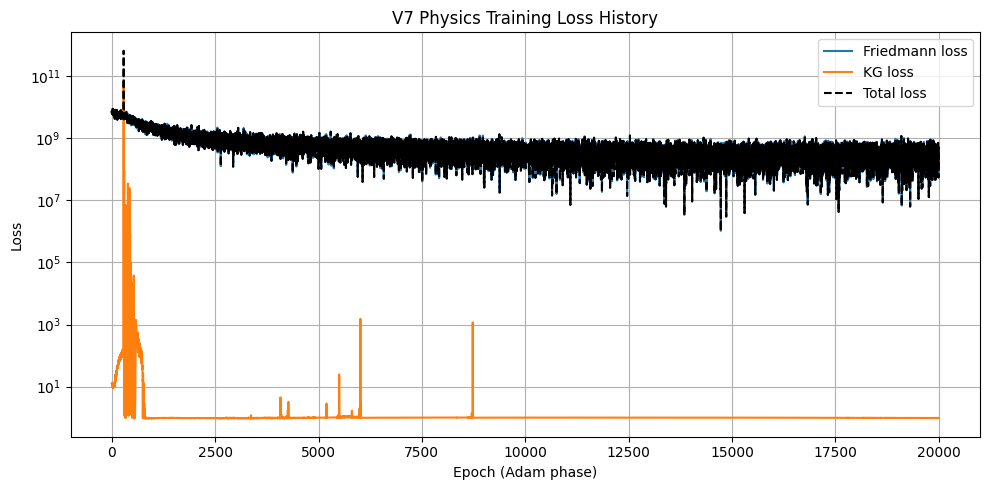

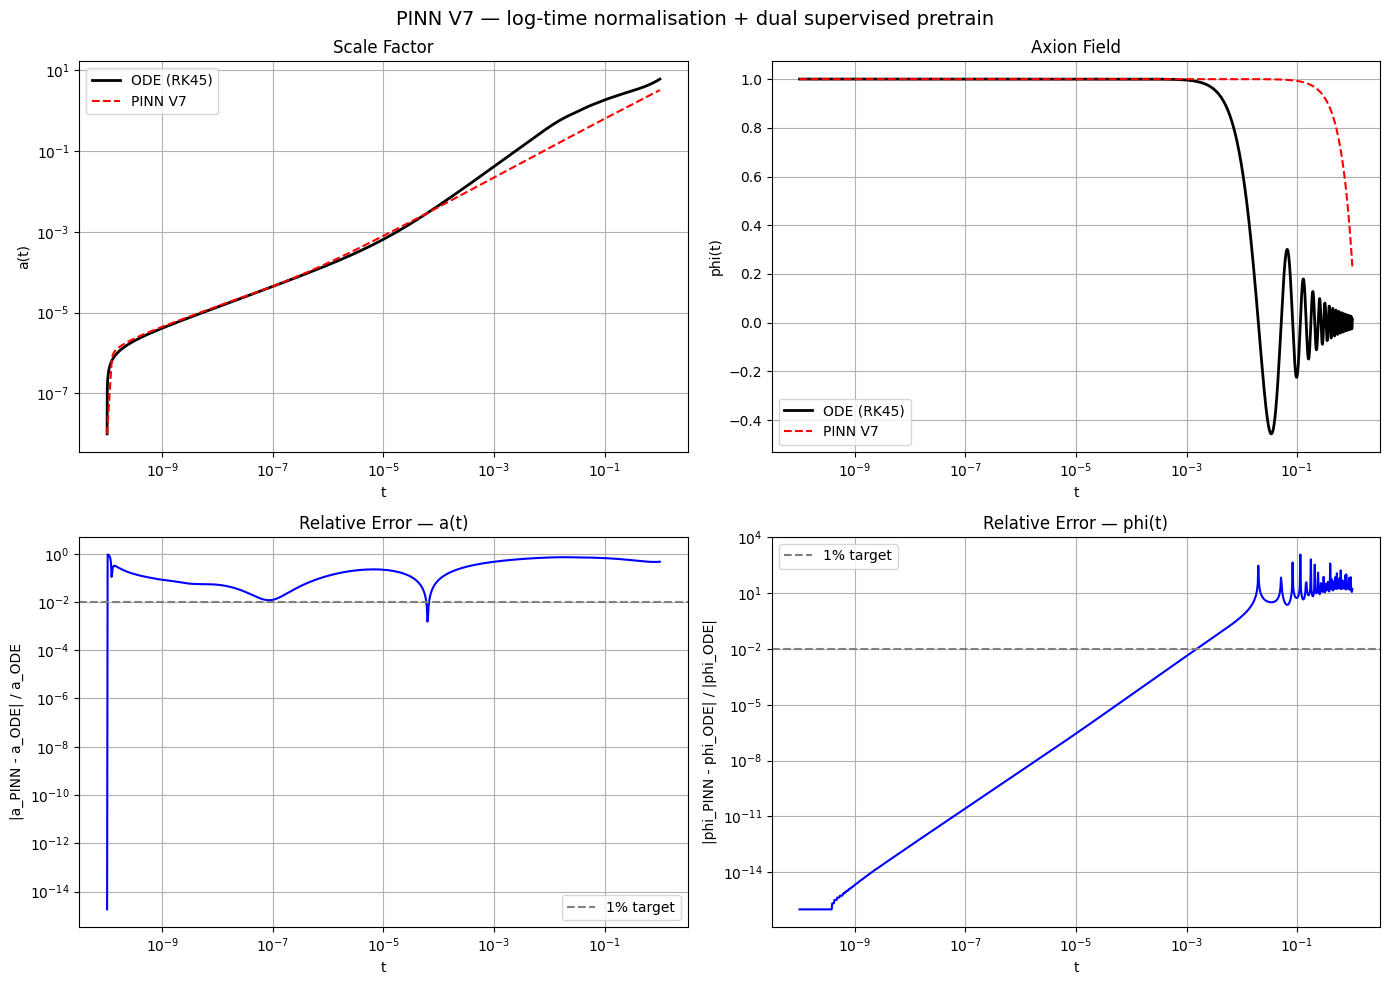

  Median rel-err a:   1.808e-01
  Median rel-err phi: 2.825e-07
  Max    rel-err a:   9.216e-01
  Max    rel-err phi: 1.171e+03


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION + PLOTS
# ─────────────────────────────────────────────────────────────────────────────
plot_loss_v7(solver_v7,    save_dir="results_v7")
plot_results_v7(solver_v7, save_dir="results_v7")
